<a href="https://colab.research.google.com/github/Nithin-M11/ai-student-learning-insights/blob/main/AI_Student_Learning_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 AI-Powered Student Report and Learning Insights

### A Data Science and Machine Learning Project

This project analyzes student academic and behavioral data to generate
personalized learning insights, predict student performance, and provide
individualized recommendations.

## 🎯 Project Objective

The objective of this project is to analyze student performance data and
develop an AI-powered system that can:

- Analyze academic performance
- Identify strongest and weakest subjects
- Analyze study habits, attendance, and assignments
- Generate personalized learning insights
- Predict student performance using Machine Learning
- Provide personalized action plans
- Generate an attractive student performance report

In [2]:
import numpy as np

study_hours = np.random.randint(5, 21, 10)

print(study_hours)

[10  5 16 16  9  8  5  7  9 11]


## 1. Dataset Generation

A synthetic dataset containing 1,000 student records is used for this project.

The dataset contains academic performance, study habits, attendance,
assignment performance, previous scores, and current scores.

In [3]:
import numpy as np

np.random.seed(42)

n_students = 1000

study_hours = np.random.randint(5, 21, n_students)
attendance = np.random.randint(50, 101, n_students)
assignment_score = np.random.randint(40, 101, n_students)
previous_score = np.random.randint(40, 101, n_students)

maths = np.random.randint(40, 101, n_students)
dbms = np.random.randint(40, 101, n_students)
python_score = np.random.randint(40, 101, n_students)
os = np.random.randint(40, 101, n_students)
ml = np.random.randint(40, 101, n_students)

### 1.1 Generating Current Performance Score

In [4]:
current_score = (
    0.20 * (study_hours / 20 * 100) +
    0.15 * attendance +
    0.15 * assignment_score +
    0.15 * previous_score +
    0.07 * maths +
    0.07 * dbms +
    0.07 * python_score +
    0.07 * os +
    0.07 * ml
)


noise = np.random.normal(0, 4, n_students)

current_score = current_score + noise

current_score = np.clip(current_score, 0, 100)

current_score = np.round(current_score, 2)

In [5]:
print(current_score[:10])

print("Minimum:", current_score.min())
print("Maximum:", current_score.max())
print("Average:", current_score.mean())

[69.96 51.22 61.19 77.91 68.46 60.47 77.04 65.43 70.96 51.07]
Minimum: 46.66
Maximum: 100.0
Average: 69.45427


In [6]:
print(study_hours[:10])
print(attendance[:10])
print(maths[:10])

[11  8 17 19 15 12 17  9 11 14]
[66 58 82 69 62 77 97 78 62 95]
[79 95 67 86 78 45 48 59 99 40]


### 1.2 Performance Level Classification

In [7]:
performance_level = np.where(
    current_score >= 90, "Excellent",
    np.where(
        current_score >= 75, "Good",
        np.where(
            current_score >= 60, "Average",
            "Needs Improvement"
        )
    )
)

print(performance_level[:20])

['Average' 'Needs Improvement' 'Average' 'Good' 'Average' 'Average' 'Good'
 'Average' 'Average' 'Needs Improvement' 'Average' 'Average' 'Average'
 'Good' 'Average' 'Average' 'Average' 'Average' 'Good' 'Average']


In [8]:
unique, counts = np.unique(performance_level, return_counts=True)

for category, count in zip(unique, counts):
    print(category, ":", count)

Average : 606
Excellent : 4
Good : 258
Needs Improvement : 132


In [9]:
print("Minimum:", current_score.min())
print("Maximum:", current_score.max())
print("Mean:", current_score.mean())
print("Median:", np.median(current_score))

Minimum: 46.66
Maximum: 100.0
Mean: 69.45427
Median: 69.12


## 2. Creating the Student DataFrame

In [10]:
import pandas as pd

data = {
    "student_id": [f"ST{i:04d}" for i in range(1, n_students + 1)],
    "study_hours": study_hours,
    "attendance": attendance,
    "assignment_score": assignment_score,
    "previous_score": previous_score,
    "maths": maths,
    "dbms": dbms,
    "python": python_score,
    "os": os,
    "ml": ml,
    "current_score": current_score,
    "performance_level": performance_level
}

df = pd.DataFrame(data)

In [11]:
df.head()

,student_id,study_hours,attendance,assignment_score,previous_score,maths,dbms,python,os,ml,current_score,performance_level
0,ST0001,11,66,64,59,79,65,94,89,46,69.96,Average
1,ST0002,8,58,44,45,95,77,79,59,61,51.22,Needs Improvement
2,ST0003,17,82,50,61,67,40,60,51,56,61.19,Average
3,ST0004,19,69,98,57,86,59,41,62,57,77.91,Good
4,ST0005,15,62,73,47,78,94,76,43,88,68.46,Average


In [12]:
df.shape

(1000, 12)

## 3. Exploratory Data Analysis

### 3.1 Data Information and Summary

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   student_id         1000 non-null   object 
 1   study_hours        1000 non-null   int64  
 2   attendance         1000 non-null   int64  
 3   assignment_score   1000 non-null   int64  
 4   previous_score     1000 non-null   int64  
 5   maths              1000 non-null   int64  
 6   dbms               1000 non-null   int64  
 7   python             1000 non-null   int64  
 8   os                 1000 non-null   int64  
 9   ml                 1000 non-null   int64  
 10  current_score      1000 non-null   float64
 11  performance_level  1000 non-null   object 
dtypes: float64(1), int64(9), object(2)
memory usage: 93.9+ KB


In [14]:
df.describe()

,study_hours,attendance,assignment_score,previous_score,maths,dbms,python,os,ml,current_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,12.570000,75.354000,69.606000,69.774000,70.458000,70.531000,70.756000,70.414000,70.668000,69.454270
std,4.666785,14.912984,17.526093,17.513185,17.414003,17.830731,17.500878,17.721587,17.653992,7.927453
min,5.000000,50.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,46.660000
25%,8.000000,62.000000,54.000000,55.000000,56.000000,56.000000,56.000000,55.000000,56.000000,63.987500
50%,13.000000,75.000000,69.500000,69.000000,71.000000,71.000000,70.000000,70.000000,70.000000,69.120000
75%,17.000000,88.000000,84.250000,85.000000,85.250000,86.000000,86.000000,86.000000,86.000000,75.235000
max,20.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [15]:
df.isnull().sum()

,0
student_id,0
study_hours,0
attendance,0
assignment_score,0
previous_score,0
maths,0
dbms,0
python,0
os,0
ml,0


In [16]:
df["performance_level"].value_counts()

,count
performance_level,
Average,606
Good,258
Needs Improvement,132
Excellent,4


### 3.2 Study Hours vs Current Score

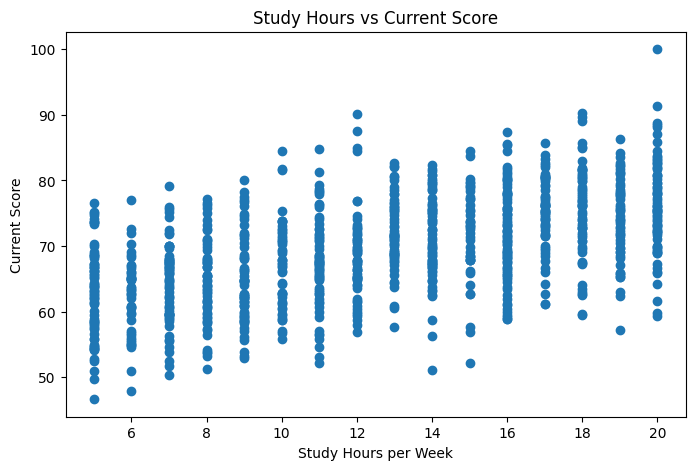

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(df["study_hours"], df["current_score"])

plt.xlabel("Study Hours per Week")
plt.ylabel("Current Score")
plt.title("Study Hours vs Current Score")

plt.show()

In [18]:
correlation = df["study_hours"].corr(df["current_score"])

print("Correlation:", correlation)

Correlation: 0.5588412156430693


### 3.3 Attendance vs Current Score

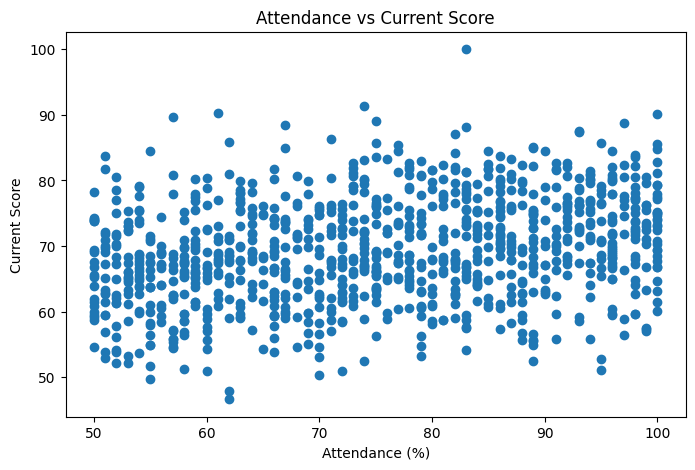

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(df["attendance"], df["current_score"])

plt.xlabel("Attendance (%)")
plt.ylabel("Current Score")
plt.title("Attendance vs Current Score")

plt.show()

In [20]:
correlation_attendance = df["attendance"].corr(df["current_score"])

print("Attendance Correlation:", correlation_attendance)

Attendance Correlation: 0.2827046308901737


### 3.4 Assignment Score vs Current Score

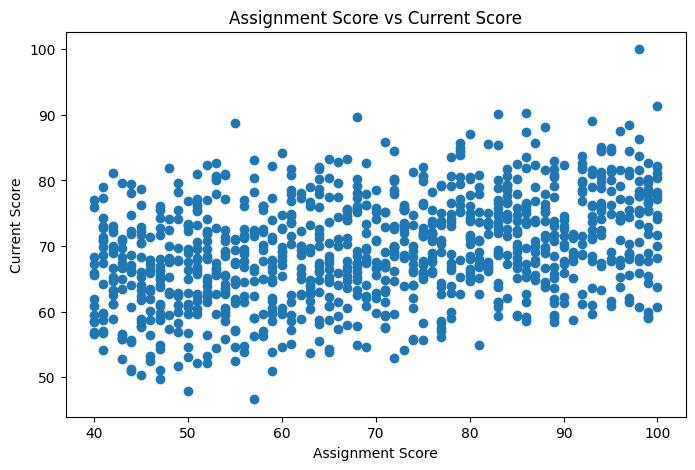

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(df["assignment_score"], df["current_score"])

plt.xlabel("Assignment Score")
plt.ylabel("Current Score")
plt.title("Assignment Score vs Current Score")

plt.show()

In [22]:
assignment_correlation = df["assignment_score"].corr(df["current_score"])

print("Assignment Correlation:", assignment_correlation)

Assignment Correlation: 0.3662776702689796


### 3.5 Previous Score vs Current Score

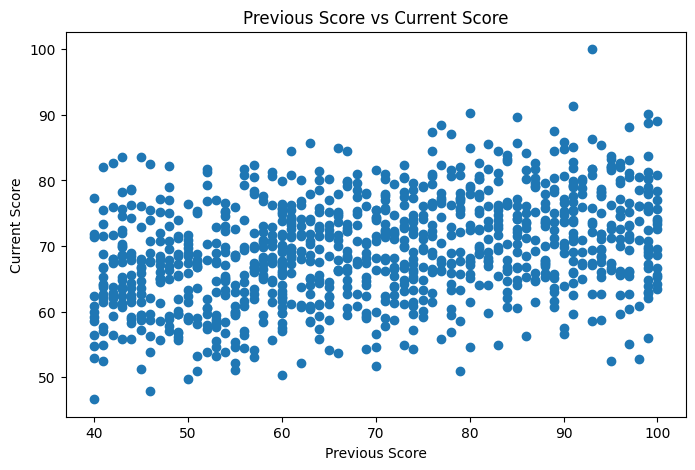

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(df["previous_score"], df["current_score"])

plt.xlabel("Previous Score")
plt.ylabel("Current Score")
plt.title("Previous Score vs Current Score")

plt.show()

In [24]:
previous_correlation = df["previous_score"].corr(df["current_score"])

print("Previous Score Correlation:", previous_correlation)

Previous Score Correlation: 0.34507957006312506


### 3.6 Correlation Analysis

In [25]:
correlation_matrix = df.corr(numeric_only=True)

correlation_with_score = correlation_matrix["current_score"].sort_values(
    ascending=False
)

print(correlation_with_score)

current_score       1.000000
study_hours         0.558841
assignment_score    0.366278
previous_score      0.345080
attendance          0.282705
python              0.170677
maths               0.160816
ml                  0.147576
os                  0.146165
dbms                0.131111
Name: current_score, dtype: float64


In [26]:
df.corr(numeric_only=True)

,study_hours,attendance,assignment_score,previous_score,maths,dbms,python,os,ml,current_score
study_hours,1.000000,-0.014754,0.012172,0.011376,-0.027776,-0.059061,-0.000881,-0.038925,-0.051902,0.558841
attendance,-0.014754,1.000000,0.038584,0.039565,0.013656,-0.006166,0.013909,0.022046,0.007834,0.282705
assignment_score,0.012172,0.038584,1.000000,0.018273,0.037523,0.006413,0.031173,0.004474,0.049238,0.366278
previous_score,0.011376,0.039565,0.018273,1.000000,0.015353,-0.043066,-0.006189,-0.013090,-0.000793,0.345080
maths,-0.027776,0.013656,0.037523,0.015353,1.000000,-0.018431,0.020386,0.025308,0.028908,0.160816
dbms,-0.059061,-0.006166,0.006413,-0.043066,-0.018431,1.000000,0.027339,0.044892,0.033232,0.131111
python,-0.000881,0.013909,0.031173,-0.006189,0.020386,0.027339,1.000000,0.029936,-0.016232,0.170677
os,-0.038925,0.022046,0.004474,-0.013090,0.025308,0.044892,0.029936,1.000000,-0.028926,0.146165
ml,-0.051902,0.007834,0.049238,-0.000793,0.028908,0.033232,-0.016232,-0.028926,1.000000,0.147576
current_score,0.558841,0.282705,0.366278,0.345080,0.160816,0.131111,0.170677,0.146165,0.147576,1.000000


## 4. Subject-Level Analysis


In [27]:
subjects = ["maths", "dbms", "python", "os", "ml"]

df["strongest_subject"] = df[subjects].idxmax(axis=1)
df["weakest_subject"] = df[subjects].idxmin(axis=1)

In [28]:
df[[
    "student_id",
    "maths",
    "dbms",
    "python",
    "os",
    "ml",
    "strongest_subject",
    "weakest_subject"
]].head(10)

,student_id,maths,dbms,python,os,ml,strongest_subject,weakest_subject
0,ST0001,79,65,94,89,46,python,ml
1,ST0002,95,77,79,59,61,maths,os
2,ST0003,67,40,60,51,56,maths,dbms
3,ST0004,86,59,41,62,57,maths,python
4,ST0005,78,94,76,43,88,dbms,os
5,ST0006,45,67,45,62,80,ml,maths
6,ST0007,48,55,83,87,49,os,maths
7,ST0008,59,86,57,94,49,os,ml
8,ST0009,99,56,69,87,96,maths,dbms
9,ST0010,40,79,61,40,46,dbms,maths


In [29]:
subjects = ["maths", "dbms", "python", "os", "ml"]

df["strongest_subject"] = df[subjects].idxmax(axis=1)
df["weakest_subject"] = df[subjects].idxmin(axis=1)

## 5. Student Performance Analysis

### 5.1 Subject-wise Performance Analysis
Analyze the average performance of students across different subjects.

In [30]:
subjects = ["maths", "dbms", "python", "os", "ml"]

subject_averages = df[subjects].mean().sort_values(ascending=False)

print("Average Score by Subject:")
print(subject_averages)

Average Score by Subject:
python    70.756
ml        70.668
dbms      70.531
maths     70.458
os        70.414
dtype: float64


### 5.2 Average Score by Subject

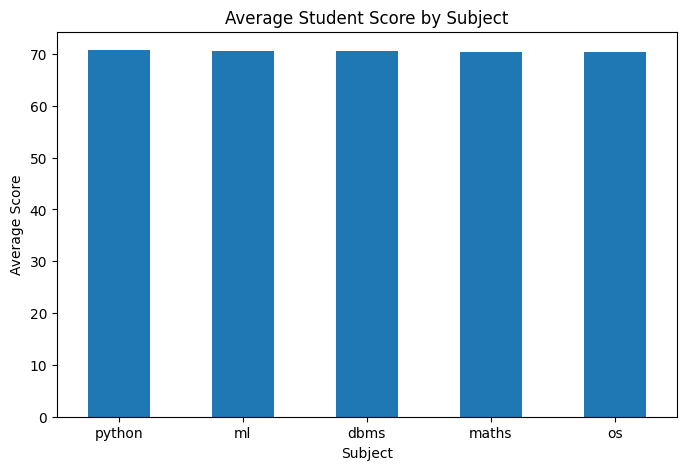

In [31]:
plt.figure(figsize=(8, 5))

subject_averages.plot(kind="bar")

plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.title("Average Student Score by Subject")

plt.xticks(rotation=0)
plt.show()

### 5.3 Strongest and Weakest Subjects

In [32]:
strongest_subject = subject_averages.idxmax()
weakest_subject = subject_averages.idxmin()

print("Overall Strongest Subject:", strongest_subject)
print("Overall Weakest Subject:", weakest_subject)

Overall Strongest Subject: python
Overall Weakest Subject: os


### 5.4 Students Needing Attention by Subject

In [33]:
weak_subject_counts = {}

for subject in subjects:
    weak_subject_counts[subject] = (df[subject] < 50).sum()

print("Students needing attention in each subject:")
print(weak_subject_counts)

Students needing attention in each subject:
{'maths': np.int64(146), 'dbms': np.int64(168), 'python': np.int64(137), 'os': np.int64(148), 'ml': np.int64(155)}


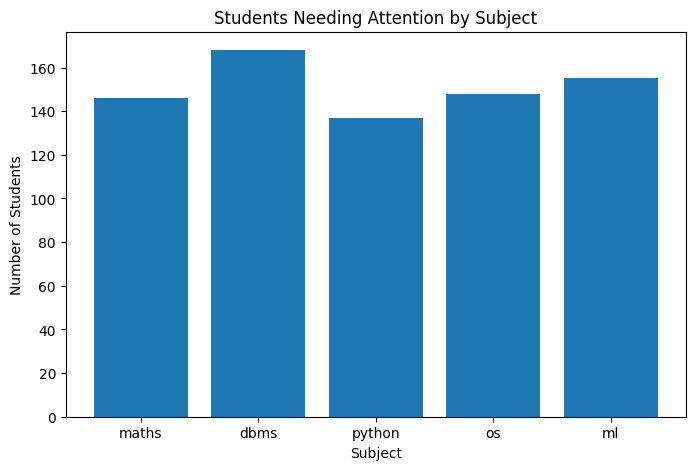

In [34]:
plt.figure(figsize=(8, 5))

plt.bar(weak_subject_counts.keys(), weak_subject_counts.values())

plt.xlabel("Subject")
plt.ylabel("Number of Students")
plt.title("Students Needing Attention by Subject")

plt.show()

## 6. Personalized Learning Insights

### 6.1 Generating Learning Recommendations

In [35]:
def generate_recommendation(row):

    weakest = row["weakest_subject"]

    if row["current_score"] < 50:
        return f"Focus strongly on {weakest} and improve overall study consistency."

    elif row["attendance"] < 70:
        return f"Improve attendance and give additional attention to {weakest}."

    elif row["study_hours"] < 10:
        return f"Increase study time and focus more on {weakest}."

    elif row["assignment_score"] < 60:
        return f"Complete assignments regularly and practice more in {weakest}."

    else:
        return f"Maintain your current performance and strengthen {weakest} further."
        df["learning_recommendation"] = df.apply(generate_recommendation, axis=1)

In [36]:
    df["learning_recommendation"] = df.apply(generate_recommendation, axis=1)

In [37]:
df[[
    "student_id",
    "current_score",
    "performance_level",
    "strongest_subject",
    "weakest_subject",
    "learning_recommendation"
]].head(10)

,student_id,current_score,performance_level,strongest_subject,weakest_subject,learning_recommendation
0,ST0001,69.96,Average,python,ml,Improve attendance and give additional attenti...
1,ST0002,51.22,Needs Improvement,maths,os,Improve attendance and give additional attenti...
2,ST0003,61.19,Average,maths,dbms,Complete assignments regularly and practice mo...
3,ST0004,77.91,Good,maths,python,Improve attendance and give additional attenti...
4,ST0005,68.46,Average,dbms,os,Improve attendance and give additional attenti...
5,ST0006,60.47,Average,ml,maths,Maintain your current performance and strength...
6,ST0007,77.04,Good,os,maths,Maintain your current performance and strength...
7,ST0008,65.43,Average,os,ml,Increase study time and focus more on ml.
8,ST0009,70.96,Average,maths,dbms,Improve attendance and give additional attenti...
9,ST0010,51.07,Needs Improvement,dbms,maths,Complete assignments regularly and practice mo...


### 6.2 Improved Personalized Learning Insights

In [38]:
def generate_detailed_insight(row):

    insights = []

    # Weak subject
    insights.append(
        f"Focus more on {row['weakest_subject'].upper()} as it is your weakest subject."
    )

    # Study habits
    if row["study_hours"] < 10:
        insights.append(
            "Increase your weekly study time."
        )
    elif row["study_hours"] >= 15:
        insights.append(
            "Your study time is good. Maintain this consistency."
        )

    # Attendance
    if row["attendance"] < 70:
        insights.append(
            "Improve your attendance."
        )
    elif row["attendance"] >= 85:
        insights.append(
            "Your attendance is good. Keep maintaining it."
        )

    # Assignments
    if row["assignment_score"] < 60:
        insights.append(
            "Spend more time completing and practicing assignments."
        )

    # Overall performance
    if row["current_score"] >= 75:
        insights.append(
            "Overall performance is good. Focus on strengthening your weak areas."
        )
    elif row["current_score"] < 50:
        insights.append(
            "Overall performance needs improvement. Follow a consistent study plan."
        )

    return " ".join(insights)
df["detailed_insight"] = df.apply(generate_detailed_insight, axis=1)

In [39]:
df[[
    "student_id",
    "current_score",
    "strongest_subject",
    "weakest_subject",
    "detailed_insight"
]].head(10)

,student_id,current_score,strongest_subject,weakest_subject,detailed_insight
0,ST0001,69.96,python,ml,Focus more on ML as it is your weakest subject...
1,ST0002,51.22,maths,os,Focus more on OS as it is your weakest subject...
2,ST0003,61.19,maths,dbms,Focus more on DBMS as it is your weakest subje...
3,ST0004,77.91,maths,python,Focus more on PYTHON as it is your weakest sub...
4,ST0005,68.46,dbms,os,Focus more on OS as it is your weakest subject...
5,ST0006,60.47,ml,maths,Focus more on MATHS as it is your weakest subj...
6,ST0007,77.04,os,maths,Focus more on MATHS as it is your weakest subj...
7,ST0008,65.43,os,ml,Focus more on ML as it is your weakest subject...
8,ST0009,70.96,maths,dbms,Focus more on DBMS as it is your weakest subje...
9,ST0010,51.07,dbms,maths,Focus more on MATHS as it is your weakest subj...


## 7. Student Performance Report

### 7.1 Generate an Individual Student Report

In [40]:
def generate_student_report(student_id):

    student = df[df["student_id"] == student_id].iloc[0]

    print("=" * 50)
    print("       STUDENT PERFORMANCE REPORT")
    print("=" * 50)

    print(f"Student ID       : {student['student_id']}")
    print(f"Current Score    : {student['current_score']}")
    print(f"Performance      : {student['performance_level']}")

    print("\n--- Academic Performance ---")
    print(f"Strongest Subject: {student['strongest_subject'].upper()}")
    print(f"Weakest Subject  : {student['weakest_subject'].upper()}")

    print("\n--- Study Profile ---")
    print(f"Study Hours      : {student['study_hours']} hours/week")
    print(f"Attendance       : {student['attendance']}%")
    print(f"Assignment Score : {student['assignment_score']}")

    print("\n--- Personalized Insight ---")
    print(student["detailed_insight"])

    print("=" * 50)

In [41]:
generate_student_report("ST0007")

       STUDENT PERFORMANCE REPORT
Student ID       : ST0007
Current Score    : 77.04
Performance      : Good

--- Academic Performance ---
Strongest Subject: OS
Weakest Subject  : MATHS

--- Study Profile ---
Study Hours      : 17 hours/week
Attendance       : 97%
Assignment Score : 99

--- Personalized Insight ---
Focus more on MATHS as it is your weakest subject. Your study time is good. Maintain this consistency. Your attendance is good. Keep maintaining it. Overall performance is good. Focus on strengthening your weak areas.


### 7.2 Subject-wise Performance

In [42]:
def get_subject_performance(student):

    performance = {}

    for subject in subjects:
        score = student[subject]

        if score >= 75:
            performance[subject] = "Good"
        elif score >= 50:
            performance[subject] = "Average"
        else:
            performance[subject] = "Needs Improvement"

    return performance

In [43]:
student = df[df["student_id"] == "ST0001"].iloc[0]

subject_performance = get_subject_performance(student)

print(subject_performance)

{'maths': 'Good', 'dbms': 'Average', 'python': 'Good', 'os': 'Good', 'ml': 'Needs Improvement'}


### 7.3 Complete Student Performance Report

In [44]:
def generate_student_report(student_id):

    student = df[df["student_id"] == student_id].iloc[0]

    subject_performance = get_subject_performance(student)

    print("=" * 55)
    print("          STUDENT PERFORMANCE REPORT")
    print("=" * 55)

    print(f"Student ID       : {student['student_id']}")
    print(f"Current Score    : {student['current_score']}")
    print(f"Performance      : {student['performance_level']}")

    print("\n--- Subject-wise Performance ---")

    for subject in subjects:
        print(
            f"{subject.upper():<10}: "
            f"{student[subject]:.0f} - "
            f"{subject_performance[subject]}"
        )

    print("\n--- Study Profile ---")
    print(f"Study Hours      : {student['study_hours']} hours/week")
    print(f"Attendance       : {student['attendance']}%")
    print(f"Assignment Score : {student['assignment_score']}")

    print("\n--- Overall Analysis ---")
    print(f"Strongest Subject: {student['strongest_subject'].upper()}")
    print(f"Weakest Subject  : {student['weakest_subject'].upper()}")

    print("\n--- Personalized Learning Insight ---")
    print(student["detailed_insight"])

    print("=" * 55)

In [45]:
generate_student_report("ST0007")

          STUDENT PERFORMANCE REPORT
Student ID       : ST0007
Current Score    : 77.04
Performance      : Good

--- Subject-wise Performance ---
MATHS     : 48 - Needs Improvement
DBMS      : 55 - Average
PYTHON    : 83 - Good
OS        : 87 - Good
ML        : 49 - Needs Improvement

--- Study Profile ---
Study Hours      : 17 hours/week
Attendance       : 97%
Assignment Score : 99

--- Overall Analysis ---
Strongest Subject: OS
Weakest Subject  : MATHS

--- Personalized Learning Insight ---
Focus more on MATHS as it is your weakest subject. Your study time is good. Maintain this consistency. Your attendance is good. Keep maintaining it. Overall performance is good. Focus on strengthening your weak areas.


### 7.4 Attractive Student Performance Report

In [76]:
from IPython.display import display, HTML

def display_student_report(student_id):

    student = df[df["student_id"] == student_id].iloc[0]

    subject_performance = get_subject_performance(student)
    action_plan = generate_action_plan(student)

    # Create subject rows
    subject_rows = ""

    for subject in subjects:

        score = student[subject]
        level = subject_performance[subject]

        if level == "Good":
            badge = '<span class="badge good">Good</span>'
        elif level == "Average":
            badge = '<span class="badge average">Average</span>'
        else:
            badge = '<span class="badge improve">Needs Improvement</span>'

        subject_rows += f"""
        <tr>
            <td><strong>{subject.upper()}</strong></td>
            <td><strong>{score:.0f}</strong></td>
            <td>
                <div class="bar">
                    <div class="fill" style="width:{score}%"></div>
                </div>
            </td>
            <td>{badge}</td>
        </tr>
        """

    # Create action plan
    action_items = ""

    for action in action_plan:
        action_items += f"<li>{action}</li>"

    report = f"""
    <style>

    .report {{
        max-width: 850px;
        margin: 20px auto;
        padding: 32px;
        font-family: Arial, sans-serif;

        background: #f4f6f8;
        color: #1f2937;

        border-radius: 18px;
        border: 1px solid #d1d5db;

        box-shadow: 0 6px 20px rgba(0,0,0,0.15);
    }}

    .header {{
        text-align: center;
        margin-bottom: 30px;
    }}

    .header h1 {{
        color: #111827;
        font-size: 30px;
        margin-bottom: 8px;
    }}

    .header p {{
        color: #374151;
        font-size: 15px;
    }}

    .cards {{
        display: flex;
        gap: 15px;
        margin-bottom: 25px;
    }}

    .card {{
        flex: 1;
        padding: 20px;
        text-align: center;

        background: #ffffff;
        border: 1px solid #d1d5db;
        border-radius: 12px;

        box-shadow: 0 2px 8px rgba(0,0,0,0.08);
    }}

    .card h4 {{
        color: #4b5563;
        margin: 0;
        font-size: 14px;
    }}

    .card h2 {{
        color: #111827;
        margin: 10px 0 0;
        font-size: 22px;
    }}

    .ai-card {{
        padding: 22px;
        margin-bottom: 25px;

        background: #e0efff;
        border-left: 6px solid #2563eb;
        border-radius: 10px;

        color: #1e3a5f;
    }}

    .ai-card h2 {{
        color: #1e40af;
        margin-top: 0;
    }}

    .section {{
        margin-top: 30px;
    }}

    .section h2 {{
        color: #111827;
        border-bottom: 2px solid #cbd5e1;
        padding-bottom: 9px;
        font-size: 21px;
    }}

    table {{
        width: 100%;
        border-collapse: collapse;
        margin-top: 15px;
        background: #ffffff;
        border-radius: 10px;
        overflow: hidden;
    }}

    th {{
        background: #dbe1e8;
        color: #111827;
        padding: 13px;
        text-align: left;
    }}

    td {{
        color: #1f2937;
        padding: 13px;
        border-bottom: 1px solid #d1d5db;
    }}

    .bar {{
        width: 180px;
        height: 10px;
        background: #d1d5db;
        border-radius: 10px;
    }}

    .fill {{
        height: 10px;
        background: #2563eb;
        border-radius: 10px;
    }}

    .badge {{
        padding: 6px 11px;
        border-radius: 20px;
        font-size: 12px;
        font-weight: bold;
    }}

    .good {{
        background: #bbf7d0;
        color: #14532d;
    }}

    .average {{
        background: #fde68a;
        color: #78350f;
    }}

    .improve {{
        background: #fecaca;
        color: #7f1d1d;
    }}

    .profile {{
        display: flex;
        justify-content: space-around;
        gap: 15px;

        background: #ffffff;
        padding: 22px;

        border: 1px solid #d1d5db;
        border-radius: 12px;
    }}

    .profile-item {{
        text-align: center;
        color: #1f2937;
    }}

    .profile-item b {{
        color: #374151;
    }}

    .insight {{
        background: #fff7ed;
        color: #431407;

        padding: 20px;

        border-left: 6px solid #f97316;
        border-radius: 9px;

        line-height: 1.7;
    }}

    .action {{
        background: #ecfdf5;
        color: #064e3b;

        padding: 20px;

        border-left: 6px solid #16a34a;
        border-radius: 9px;

        line-height: 1.8;
    }}

    .action li {{
        margin-bottom: 6px;
    }}

    </style>


    <div class="report">

        <div class="header">

            <h1>Student Performance Report</h1>

            <p>
                AI-Powered Student Learning Insights
            </p>

            <p>
                <strong>Student ID:</strong> {student['student_id']}
            </p>

        </div>


        <div class="cards">

            <div class="card">

                <h4>Current Score</h4>

                <h2>{student['current_score']:.2f}</h2>

            </div>


            <div class="card">

                <h4>Performance</h4>

                <h2>{student['performance_level']}</h2>

            </div>


            <div class="card">

                <h4>Strongest Subject</h4>

                <h2>{student['strongest_subject'].upper()}</h2>

            </div>

        </div>


        <div class="ai-card">

            <h2>AI Performance Prediction</h2>

            <p>
                <strong>Predicted Score:</strong>
                {student['predicted_score']:.2f}
            </p>

            <p>
                <strong>Predicted Performance:</strong>
                {student['predicted_performance']}
            </p>

        </div>


        <div class="section">

            <h2>Subject-wise Performance</h2>

            <table>

                <tr>
                    <th>Subject</th>
                    <th>Score</th>
                    <th>Progress</th>
                    <th>Status</th>
                </tr>

                {subject_rows}

            </table>

        </div>


        <div class="section">

            <h2>Study Profile</h2>

            <div class="profile">

                <div class="profile-item">
                    <b>Study Hours</b>
                    <br><br>
                    {student['study_hours']} hrs/week
                </div>

                <div class="profile-item">
                    <b>Attendance</b>
                    <br><br>
                    {student['attendance']}%
                </div>

                <div class="profile-item">
                    <b>Assignment Score</b>
                    <br><br>
                    {student['assignment_score']}
                </div>

            </div>

        </div>


        <div class="section">

            <h2>Personalized Learning Insight</h2>

            <div class="insight">

                {student['detailed_insight']}

            </div>

        </div>


        <div class="section">

            <h2>Recommended Action Plan</h2>

            <div class="action">

                <ol>
                    {action_items}
                </ol>

            </div>

        </div>

    </div>
    """

    display(HTML(report))

In [79]:
display_student_report("ST0033")

Subject,Score,Progress,Status
MATHS,48,,Needs Improvement
DBMS,46,,Needs Improvement
PYTHON,94,,Good
OS,91,,Good
ML,89,,Good


### 7.5 Subject Performance Visualization

In [48]:
import matplotlib.pyplot as plt

def plot_student_performance(student_id):

    student = df[df["student_id"] == student_id].iloc[0]

    subject_scores = [student[subject] for subject in subjects]

    plt.figure(figsize=(9, 5))

    plt.bar(subjects, subject_scores)

    plt.ylim(0, 100)
    plt.xlabel("Subjects")
    plt.ylabel("Score")
    plt.title(f"Subject Performance - {student_id}")

    plt.show()

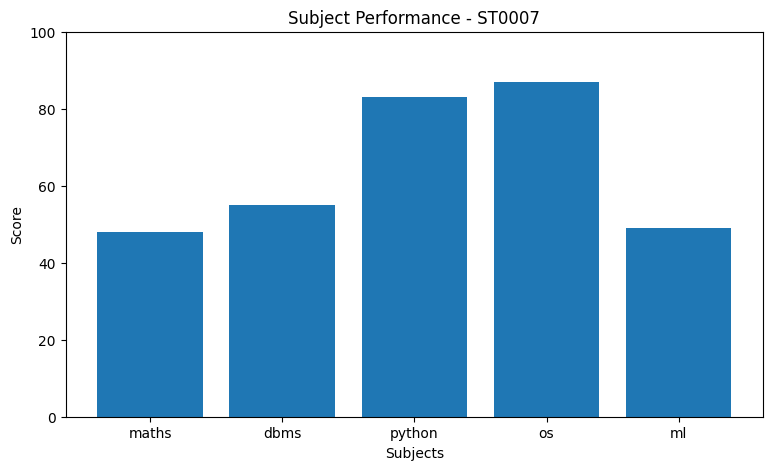

In [49]:
plot_student_performance("ST0007")

## 8. Machine Learning - Student Performance Prediction

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [51]:
features = [
    "study_hours",
    "attendance",
    "assignment_score",
    "previous_score",
    "maths",
    "dbms",
    "python",
    "os",
    "ml"
]

X = df[features]
y = df["current_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 9)
Testing data: (200, 9)


In [52]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [53]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 10 predictions:")
print(y_pred[:10])

Predictions generated successfully!
First 10 predictions:
[73.4848 78.6902 77.584  73.0784 71.9889 63.8814 62.36   62.0229 74.705
 70.4948]


In [54]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

Model Performance
------------------
MAE  : 3.83
RMSE : 4.82
R²   : 0.65


## 8.1 Feature Importance

Identify which factors contribute most to predicting student performance.

In [55]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
study_hours         0.325234
assignment_score    0.154667
previous_score      0.144840
attendance          0.106419
maths               0.057782
ml                  0.056770
python              0.056097
os                  0.049365
dbms                0.048825
dtype: float64


### 8.2 Feature Importance Visualization

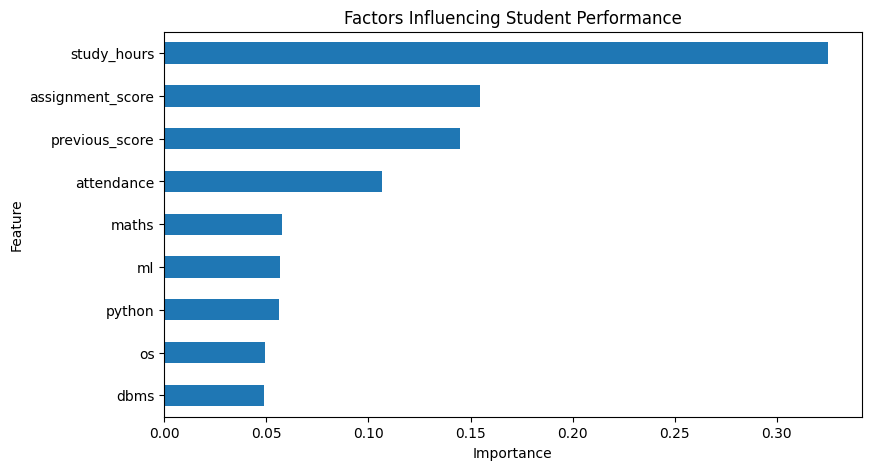

In [56]:
plt.figure(figsize=(9, 5))

feature_importance.sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Factors Influencing Student Performance")

plt.show()

### 8.3 Actual vs Predicted Scores

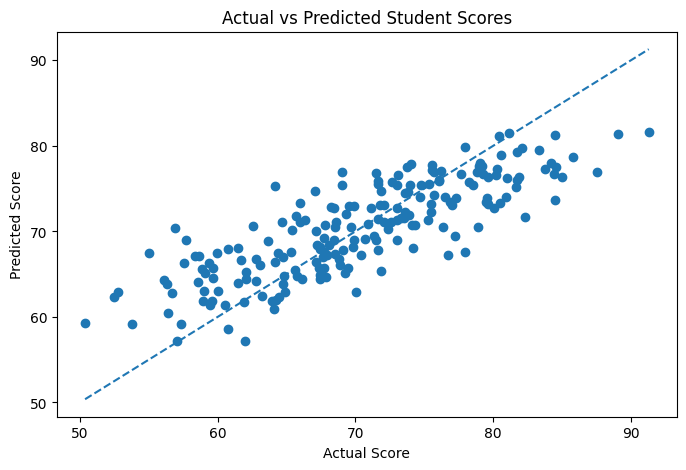

In [57]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Student Scores")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

### 8.4 Predicted Performance Category

In [60]:
def classify_score(score):

    if score >= 75:
        return "Good"
    elif score >= 50:
        return "Average"
    else:
        return "Needs Improvement"

In [61]:
predicted_categories = [classify_score(score) for score in y_pred]

print("First 10 predicted categories:")
print(predicted_categories[:10])

First 10 predicted categories:
['Average', 'Good', 'Good', 'Average', 'Average', 'Average', 'Average', 'Average', 'Average', 'Average']


In [62]:
# Predict scores for all students
df["predicted_score"] = model.predict(df[features])

# Convert predicted scores into categories
df["predicted_performance"] = df["predicted_score"].apply(classify_score)

print(df[[
    "student_id",
    "current_score",
    "predicted_score",
    "predicted_performance"
]].head(10))

  student_id  current_score  predicted_score predicted_performance
0     ST0001          69.96          67.9145               Average
1     ST0002          51.22          54.6246               Average
2     ST0003          61.19          62.4572               Average
3     ST0004          77.91          76.0787                  Good
4     ST0005          68.46          68.6572               Average
5     ST0006          60.47          62.5974               Average
6     ST0007          77.04          77.1651                  Good
7     ST0008          65.43          64.2573               Average
8     ST0009          70.96          70.7611               Average
9     ST0010          51.07          58.3844               Average


### 8.6 Personalized Action Plan

In [75]:
def generate_action_plan(row):

    actions = []

    # Weakest subject
    actions.append(
        f"Prioritize {row['weakest_subject'].upper()} during your study sessions."
    )

    # Study hours
    if row["study_hours"] < 10:
        actions.append(
            "Increase your weekly study time gradually."
        )
    elif row["study_hours"] >= 15:
        actions.append(
            "Maintain your current study consistency."
        )

    # Attendance
    if row["attendance"] < 70:
        actions.append(
            "Work on improving your class attendance."
        )
    elif row["attendance"] >= 85:
        actions.append(
            "Maintain your strong attendance."
        )

    # Assignment performance
    if row["assignment_score"] < 60:
        actions.append(
            "Spend more time completing and reviewing assignments."
        )
    elif row["assignment_score"] >= 85:
        actions.append(
            "Continue your strong assignment performance."
        )

    return actions

In [74]:
student = df[df["student_id"] == "ST0007"].iloc[0]

action_plan = generate_action_plan(student)

for i, action in enumerate(action_plan, 1):
    print(f"{i}. {action}")

1. Prioritize MATHS during your study sessions.
2. Maintain your current study consistency.
3. Maintain your strong attendance.
4. Continue your strong assignment performance.
